# Exploratory Data Analysis

**Estimated time needed: 30 minutes**

## Objectives

After completing this lab you will be able to:

- Explore features or characteristics to predict price of car
- Analyze patterns and run descriptive statistical analysis
- Group data based on identified parameters and create pivot tables
- Identify the effect of independent attributes on price of cars


## Table of Contents

1. [Import Data](#1-import-data)
2. [Analyzing Individual Feature Patterns Using Visualization](#2-analyzing-individual-feature-patterns-using-visualization)
3. [Descriptive Statistical Analysis](#3-descriptive-statistical-analysis)
4. [Basics of Grouping](#4-basics-of-grouping)
5. [Correlation and Causation](#5-correlation-and-causation)

---

### What are the main characteristics that have the most impact on the car price?


## 1. Import Data

#### Setup — Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

print('Libraries imported successfully!')

Libraries imported successfully!


#### Load the Dataset

We load the automobile dataset directly from the URL using `pd.read_csv()`.


In [2]:
file_path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv'

df = pd.read_csv(file_path, header=0)
print('Dataset loaded successfully!')
print('Shape:', df.shape)

Dataset loaded successfully!
Shape: (201, 29)


View the first 5 rows of the dataset:


In [3]:
df.head()

,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,13495.0,11.190476,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.811148,...,9.0,111.0,5000.0,21,27,16500.0,11.190476,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.822681,...,9.0,154.0,5000.0,19,26,16500.0,12.368421,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.848630,...,10.0,102.0,5500.0,24,30,13950.0,9.791667,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.848630,...,8.0,115.0,5500.0,18,22,17450.0,13.055556,Medium,0,1


---
## 2. Analyzing Individual Feature Patterns Using Visualization

#### How to choose the right visualization method?

When visualizing individual variables, it is important to first understand what **type** of variable you are dealing with:

- **Continuous numerical variables** (int64 / float64) → use scatter plots or regression plots
- **Categorical variables** (object) → use box plots

Let's first check the data types of each column:


In [4]:
# List the data type for each column
print(df.dtypes)

symboling              int64
normalized-losses      int64
make                  object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower           float64
peak-rpm             float64
city-mpg               int64
highway-mpg            int64
price                float64
city-L/100km         float64
horsepower-binned     object
diesel                 int64
gas                    int64
dtype: object


> **Question 1:** What is the data type of the column `peak-rpm`?


In [5]:
# Check data type of peak-rpm
df['peak-rpm'].dtype

dtype('float64')

We can calculate the correlation between variables of type `int64` or `float64` using the `.corr()` method:


In [6]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
numeric_df.corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


> The diagonal elements are always **1.0** — every variable is perfectly correlated with itself.

> **Question 2:** Find the correlation between: `bore`, `stroke`, `compression-ratio`, and `horsepower`.
> 
> *Hint: use `df[['bore','stroke','compression-ratio','horsepower']]`*


In [8]:
# Write your code here
df[['bore','stroke','compression-ratio','horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.000000,-0.055390,0.001263,0.566936
stroke,-0.055390,1.000000,0.187923,0.098462
compression-ratio,0.001263,0.187923,1.000000,-0.214514
horsepower,0.566936,0.098462,-0.214514,1.000000


<details><summary>Click here for the solution</summary>

```python
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()
```

</details>


### Continuous Numerical Variables

Continuous numerical variables can take any value within a range. A great way to visualize the relationship between a continuous variable and price is using `sns.regplot()`, which plots the scatter plot **plus** the fitted regression line.


#### Positive Linear Relationship

Let's look at `engine-size` vs `price`:


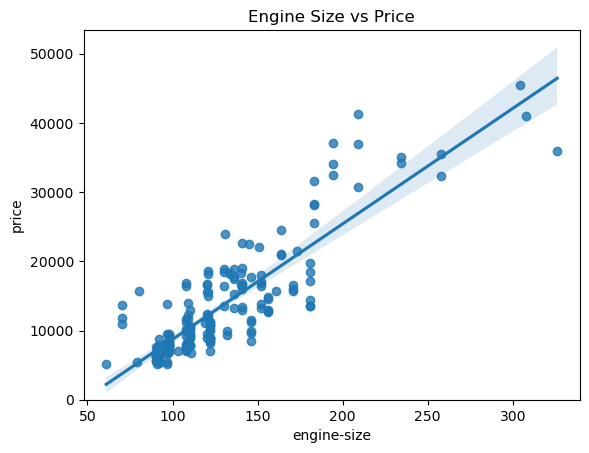

In [13]:
sns.regplot(x='engine-size', y='price', data=df)
plt.ylim(0,)
plt.title('Engine Size vs Price')
plt.show()

As engine-size goes up, the price goes up — a **positive direct correlation**. Engine size looks like a strong predictor of price since the regression line is nearly diagonal.


In [10]:
# Check correlation value
df[['engine-size', 'price']].corr()

,engine-size,price
engine-size,1.000000,0.872335
price,0.872335,1.000000


Now let's look at `highway-mpg` vs `price`:


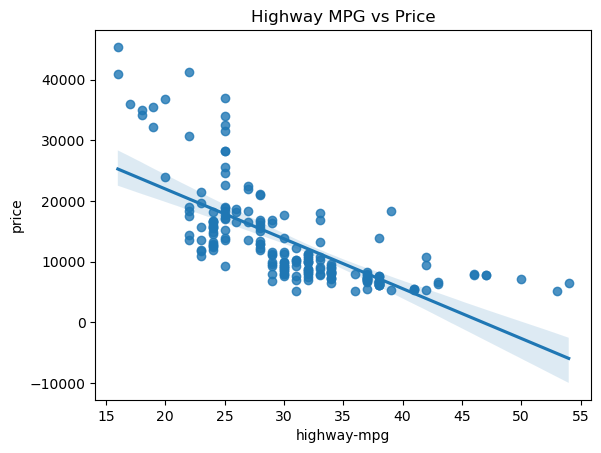

In [11]:
sns.regplot(x='highway-mpg', y='price', data=df)
plt.title('Highway MPG vs Price')
plt.show()

As highway-mpg goes up, the price goes down — a **negative (inverse) correlation**. Highway mpg could be a useful predictor of price.


In [14]:
df[['highway-mpg', 'price']].corr()

,highway-mpg,price
highway-mpg,1.000000,-0.704692
price,-0.704692,1.000000


#### Weak Linear Relationship

Let's check if `peak-rpm` predicts price:


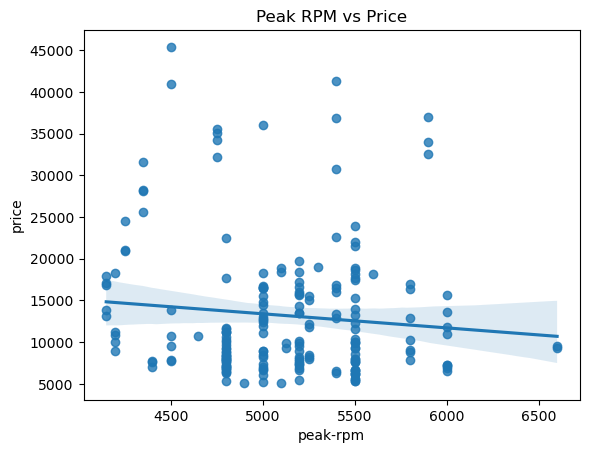

In [15]:
sns.regplot(x='peak-rpm', y='price', data=df)
plt.title('Peak RPM vs Price')
plt.show()

The regression line is nearly **flat** and the data points are widely scattered — peak-rpm is **not a reliable predictor** of price.


In [16]:
df[['peak-rpm', 'price']].corr()

,peak-rpm,price
peak-rpm,1.000000,-0.101616
price,-0.101616,1.000000


> **Question 3a:** Find the correlation between `stroke` and `price`.


In [17]:
# Write your code here
df[['stroke','price']].corr()

,stroke,price
stroke,1.00000,0.08231
price,0.08231,1.00000


<details><summary>Click here for the solution</summary>

```python
# The correlation is ~0.0823 — very weak
df[['stroke', 'price']].corr()
```

</details>


> **Question 3b:** Given the weak correlation between `stroke` and `price`, do you expect a linear relationship? Verify using `regplot()`.


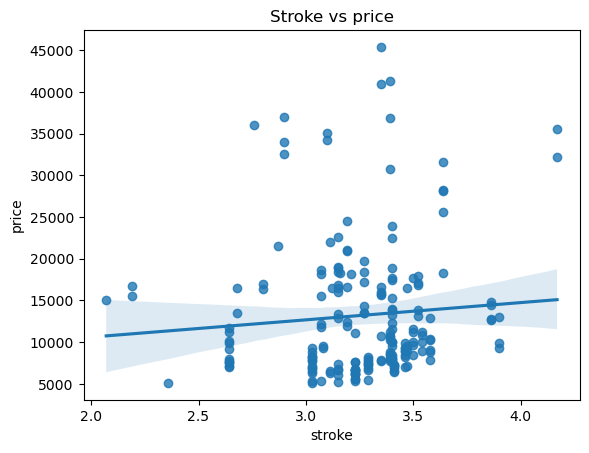

In [18]:
# Write your code here
sns.regplot(x='stroke',y='price',data=df)
plt.title('Stroke vs price')
plt.show()

<details><summary>Click here for the solution</summary>

```python
# Weak correlation → no strong linear relationship
sns.regplot(x='stroke', y='price', data=df)
plt.show()
```

</details>


### Categorical Variables

Categorical variables describe a characteristic and come from a small group of categories. The best way to visualize them against a numeric variable like price is using **box plots**.


Let's look at `body-style` vs `price`:


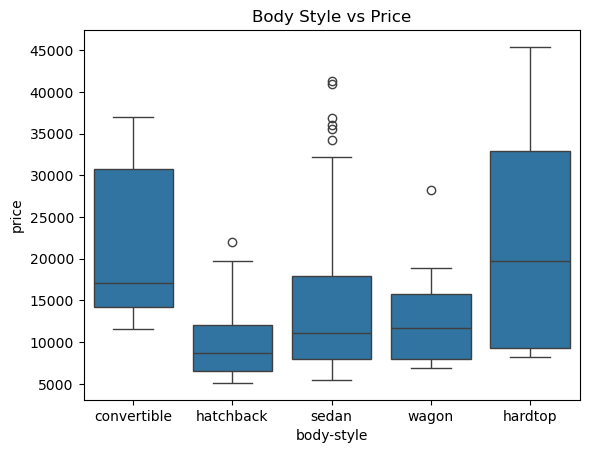

In [19]:
sns.boxplot(x='body-style', y='price', data=df)
plt.title('Body Style vs Price')
plt.show()

The price distributions across body-style categories **overlap significantly** — body-style alone is not a strong predictor of price.


Now let's look at `engine-location` vs `price`:


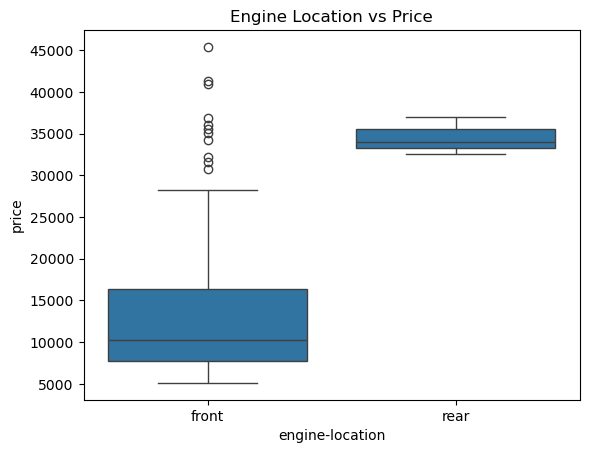

In [20]:
sns.boxplot(x='engine-location', y='price', data=df)
plt.title('Engine Location vs Price')
plt.show()

The distributions for front vs rear engine location are **clearly distinct** — engine location appears to be a good predictor of price.


Let's also check `drive-wheels` vs `price`:


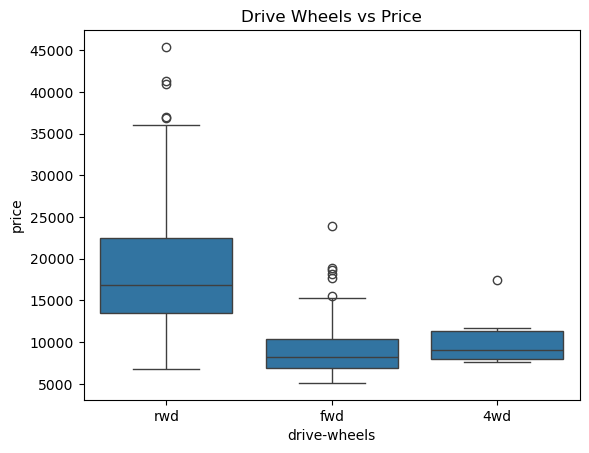

In [21]:
sns.boxplot(x='drive-wheels', y='price', data=df)
plt.title('Drive Wheels vs Price')
plt.show()

The distribution of price differs noticeably across drive-wheel types — **drive-wheels could be a useful predictor** of price.


---
## 3. Descriptive Statistical Analysis

The `describe()` function automatically computes basic statistics for all continuous numerical variables:

- **count** — number of non-null values
- **mean** — average
- **std** — standard deviation (spread)
- **min / max** — smallest and largest values
- **25% / 50% / 75%** — quartiles (IQR)


In [22]:
# Summary stats for numerical columns
df.describe()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
count,201.000000,201.00000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,197.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000,201.000000
mean,0.840796,122.00000,98.797015,0.837102,0.915126,53.766667,2555.666667,126.875622,3.330692,3.256904,10.164279,103.405534,5117.665368,25.179104,30.686567,13207.129353,9.944145,0.099502,0.900498
std,1.254802,31.99625,6.066366,0.059213,0.029187,2.447822,517.296727,41.546834,0.268072,0.319256,4.004965,37.365700,478.113805,6.423220,6.815150,7947.066342,2.534599,0.300083,0.300083
min,-2.000000,65.00000,86.600000,0.678039,0.837500,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000,4.795918,0.000000,0.000000
25%,0.000000,101.00000,94.500000,0.801538,0.890278,52.000000,2169.000000,98.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000,7.833333,0.000000,1.000000
50%,1.000000,122.00000,97.000000,0.832292,0.909722,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5125.369458,24.000000,30.000000,10295.000000,9.791667,0.000000,1.000000
75%,2.000000,137.00000,102.400000,0.881788,0.925000,55.500000,2926.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000,12.368421,0.000000,1.000000
max,3.000000,256.00000,120.900000,1.000000,1.000000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,262.000000,6600.000000,49.000000,54.000000,45400.000000,18.076923,1.000000,1.000000


We can also run `describe()` on categorical (object) columns:


In [23]:
# Summary stats for categorical columns
df.describe(include=['object'])

,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,engine-type,num-of-cylinders,fuel-system,horsepower-binned
count,201,201,201,201,201,201,201,201,201,200
unique,22,2,2,5,3,2,6,7,8,3
top,toyota,std,four,sedan,fwd,front,ohc,four,mpfi,Low
freq,32,165,115,94,118,198,145,157,92,115


### Value Counts

`value_counts()` tells us how many times each unique value appears in a column. It works on a **pandas Series** (single bracket), not a DataFrame (double bracket).


In [24]:
# Count of each drive-wheel type
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

We can convert the result to a DataFrame for cleaner display:


In [25]:
df['drive-wheels'].value_counts().to_frame()

,count
drive-wheels,
fwd,118
rwd,75
4wd,8


Let's save and rename the result properly:


In [26]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame()
drive_wheels_counts.reset_index(inplace=True)
drive_wheels_counts = drive_wheels_counts.rename(columns={'drive-wheels': 'value_counts'})
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,value_counts,count
drive-wheels,,
0,fwd,118
1,rwd,75
2,4wd,8


Let's repeat the same process for `engine-location`:


In [27]:
engine_loc_counts = df['engine-location'].value_counts().to_frame()
engine_loc_counts.rename(columns={'engine-location': 'value_counts'}, inplace=True)
engine_loc_counts.index.name = 'engine-location'
engine_loc_counts.head(10)

,count
engine-location,
front,198
rear,3


> **Note:** There are only 3 rear-engine cars vs 198 front-engine cars. This imbalance means `engine-location` may not be a reliable predictor — we don't have enough rear-engine data to draw conclusions.


---
## 4. Basics of Grouping

The `groupby()` method groups data by one or more categorical columns and lets you apply aggregate functions (like mean, sum, count) to each group.

Let's first check the unique values in `drive-wheels`:


In [28]:
df['drive-wheels'].unique()

array(['rwd', 'fwd', '4wd'], dtype=object)

Let's find the **average price** for each drive-wheel type:


In [29]:
df_group_one = df[['drive-wheels', 'body-style', 'price']]

df_grouped = df_group_one.groupby(['drive-wheels'], as_index=False).agg({'price': 'mean'})
df_grouped

,drive-wheels,price
0,4wd,10241.000000
1,fwd,9244.779661
2,rwd,19757.613333


Rear-wheel drive cars are on average the most expensive, while 4-wheel and front-wheel drive are approximately the same price.


We can also group by **multiple columns** — both `drive-wheels` and `body-style`:


In [30]:
df_gptest = df[['drive-wheels', 'body-style', 'price']]
grouped_test1 = df_gptest.groupby(['drive-wheels', 'body-style'], as_index=False).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.000000
1,4wd,sedan,12647.333333
2,4wd,wagon,9095.750000
3,fwd,convertible,11595.000000
4,fwd,hardtop,8249.000000
5,fwd,hatchback,8396.387755
6,fwd,sedan,9811.800000
7,fwd,wagon,9997.333333
8,rwd,convertible,23949.600000
9,rwd,hardtop,24202.714286


### Pivot Table

This grouped data is much easier to read as a **pivot table** — like a spreadsheet with one variable as rows and the other as columns:


In [31]:
grouped_pivot = grouped_test1.pivot(index='drive-wheels', columns='body-style')
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  NaN           NaN   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

Fill any missing combinations with 0:


In [32]:
grouped_pivot = grouped_pivot.fillna(0)
grouped_pivot

price                                            \
body-style   convertible       hardtop     hatchback         sedan   
drive-wheels                                                         
4wd                  0.0      0.000000   7603.000000  12647.333333   
fwd              11595.0   8249.000000   8396.387755   9811.800000   
rwd              23949.6  24202.714286  14337.777778  21711.833333   

                            
body-style           wagon  
drive-wheels                
4wd            9095.750000  
fwd            9997.333333  
rwd           16994.222222

> **Question 4:** Use `groupby()` to find the average price of each car based on `body-style`.


In [33]:
# Write your code here
df_gptest2 = df[['body-style','price']]
grouped_test_bodystyle = df_gptest2.groupby(['body-style'],as_index=False).mean()
grouped_test_bodystyle

,body-style,price
0,convertible,21890.500000
1,hardtop,22208.500000
2,hatchback,9957.441176
3,sedan,14459.755319
4,wagon,12371.960000


<details><summary>Click here for the solution</summary>

```python
df_gptest2 = df[['body-style', 'price']]
grouped_test_bodystyle = df_gptest2.groupby(['body-style'], as_index=False).mean()
grouped_test_bodystyle
```

</details>


### Heatmap — Drive Wheels & Body Style vs Price

We can use `plt.pcolor()` to visualize the pivot table as a heatmap. Color represents average price:


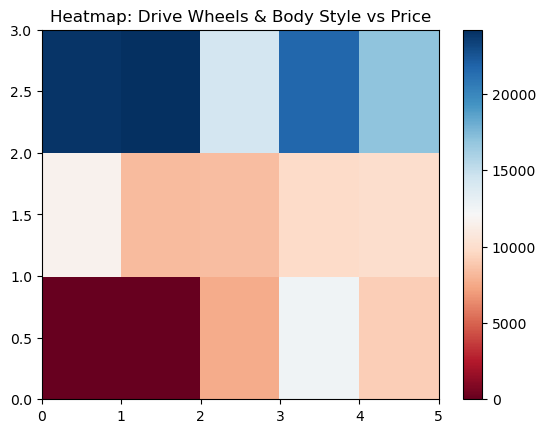

In [34]:
plt.pcolor(grouped_pivot, cmap='RdBu')
plt.colorbar()
plt.title('Heatmap: Drive Wheels & Body Style vs Price')
plt.show()

Let's add proper axis labels to make it more readable:


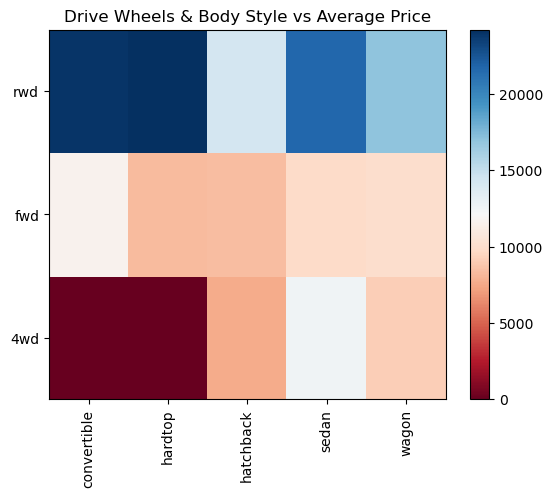

In [35]:
fig, ax = plt.subplots()
im = ax.pcolor(grouped_pivot, cmap='RdBu')

# Label names
row_labels = grouped_pivot.columns.levels[1]
col_labels  = grouped_pivot.index

# Move ticks to center of each cell
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, minor=False)
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, minor=False)

# Insert labels
ax.set_xticklabels(row_labels, minor=False)
ax.set_yticklabels(col_labels, minor=False)

plt.xticks(rotation=90)
fig.colorbar(im)
plt.title('Drive Wheels & Body Style vs Average Price')
plt.show()

---
## 5. Correlation and Causation

- **Correlation** — a measure of how strongly two variables are related.
- **Causation** — a direct cause-and-effect relationship between two variables.

> ⚠️ **Important:** Correlation does NOT imply causation. Two variables can move together due to a third hidden factor.


### Pearson Correlation

The **Pearson Correlation Coefficient** measures the linear relationship between two variables. The result is always between **-1 and +1**:

| Value | Meaning |
|---|---|
| +1 | Perfect positive linear correlation |
| 0 | No linear correlation |
| -1 | Perfect negative linear correlation |

Let's compute the full Pearson correlation matrix:


In [36]:
df.select_dtypes(include=['number']).corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.000000,0.466264,-0.535987,-0.365404,-0.242423,-0.550160,-0.233118,-0.110581,-0.140019,-0.008245,-0.182196,0.075819,0.279740,-0.035527,0.036233,-0.082391,0.066171,-0.196735,0.196735
normalized-losses,0.466264,1.000000,-0.056661,0.019424,0.086802,-0.373737,0.099404,0.112360,-0.029862,0.055563,-0.114713,0.217299,0.239543,-0.225016,-0.181877,0.133999,0.238567,-0.101546,0.101546
wheel-base,-0.535987,-0.056661,1.000000,0.876024,0.814507,0.590742,0.782097,0.572027,0.493244,0.158502,0.250313,0.371147,-0.360305,-0.470606,-0.543304,0.584642,0.476153,0.307237,-0.307237
length,-0.365404,0.019424,0.876024,1.000000,0.857170,0.492063,0.880665,0.685025,0.608971,0.124139,0.159733,0.579821,-0.285970,-0.665192,-0.698142,0.690628,0.657373,0.211187,-0.211187
width,-0.242423,0.086802,0.814507,0.857170,1.000000,0.306002,0.866201,0.729436,0.544885,0.188829,0.189867,0.615077,-0.245800,-0.633531,-0.680635,0.751265,0.673363,0.244356,-0.244356
height,-0.550160,-0.373737,0.590742,0.492063,0.306002,1.000000,0.307581,0.074694,0.180449,-0.062704,0.259737,-0.087027,-0.309974,-0.049800,-0.104812,0.135486,0.003811,0.281578,-0.281578
curb-weight,-0.233118,0.099404,0.782097,0.880665,0.866201,0.307581,1.000000,0.849072,0.644060,0.167562,0.156433,0.757976,-0.279361,-0.749543,-0.794889,0.834415,0.785353,0.221046,-0.221046
engine-size,-0.110581,0.112360,0.572027,0.685025,0.729436,0.074694,0.849072,1.000000,0.572609,0.209523,0.028889,0.822676,-0.256733,-0.650546,-0.679571,0.872335,0.745059,0.070779,-0.070779
bore,-0.140019,-0.029862,0.493244,0.608971,0.544885,0.180449,0.644060,0.572609,1.000000,-0.055390,0.001263,0.566936,-0.267392,-0.582027,-0.591309,0.543155,0.554610,0.054458,-0.054458
stroke,-0.008245,0.055563,0.158502,0.124139,0.188829,-0.062704,0.167562,0.209523,-0.055390,1.000000,0.187923,0.098462,-0.065713,-0.034696,-0.035201,0.082310,0.037300,0.241303,-0.241303


### P-value

The **p-value** tells us whether the correlation is statistically significant.

| P-value | Evidence |
|---|---|
| < 0.001 | Strong evidence — correlation is significant |
| < 0.05 | Moderate evidence |
| < 0.1 | Weak evidence |
| > 0.1 | No evidence — correlation may not be significant |

We use `scipy.stats.pearsonr()` to get both the coefficient and the p-value together.


### Wheel Base vs. Price


In [37]:
pearson_coef, p_value = stats.pearsonr(df['wheel-base'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: 0.5846418222655081
P-value: 8.076488270732885e-20


> **Conclusion:** Since the p-value is < 0.001, the correlation between `wheel-base` and price is statistically significant, although the linear relationship isn't extremely strong (~0.585).


### Horsepower vs. Price


In [38]:
pearson_coef, p_value = stats.pearsonr(df['horsepower'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: 0.809574567003656
P-value: 6.369057428259557e-48


> **Conclusion:** Since the p-value is < 0.001, the correlation between `horsepower` and price is statistically significant, and the linear relationship is quite strong (~0.809).


### Length vs. Price


In [39]:
pearson_coef, p_value = stats.pearsonr(df['length'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: 0.690628380448364
P-value: 8.016477466158868e-30


> **Conclusion:** Since the p-value is < 0.001, the correlation between `length` and price is statistically significant, and the linear relationship is moderately strong (~0.691).


### Width vs. Price


In [40]:
pearson_coef, p_value = stats.pearsonr(df['width'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: 0.7512653440522674
P-value: 9.20033551048144e-38


> **Conclusion:** Since the p-value is < 0.001, the correlation between `width` and price is statistically significant, and the linear relationship is quite strong (~0.751).


### Curb Weight vs. Price


In [41]:
pearson_coef, p_value = stats.pearsonr(df['curb-weight'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: 0.8344145257702845
P-value: 2.189577238893965e-53


> **Conclusion:** Since the p-value is < 0.001, the correlation between `curb-weight` and price is statistically significant, and the linear relationship is quite strong (~0.834).


### Engine Size vs. Price


In [42]:
pearson_coef, p_value = stats.pearsonr(df['engine-size'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: 0.8723351674455185
P-value: 9.265491622198793e-64


> **Conclusion:** Since the p-value is < 0.001, the correlation between `engine-size` and price is statistically significant, and the linear relationship is very strong (~0.872).


### Bore vs. Price


In [43]:
pearson_coef, p_value = stats.pearsonr(df['bore'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: 0.5431553832626603
P-value: 8.049189483935315e-17


> **Conclusion:** Since the p-value is < 0.001, the correlation between `bore` and price is statistically significant, but the linear relationship is only moderate (~0.521).


### City Mpg vs. Price


In [44]:
pearson_coef, p_value = stats.pearsonr(df['city-mpg'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: -0.6865710067844679
P-value: 2.3211320655675098e-29


> **Conclusion:** Since the p-value is < 0.001, the correlation between `city-mpg` and price is statistically significant, and the coefficient shows a negative moderately strong relationship (~-0.687).


### Highway Mpg vs. Price


In [45]:
pearson_coef, p_value = stats.pearsonr(df['highway-mpg'], df['price'])
print('Pearson Correlation Coefficient:', pearson_coef)
print('P-value:', p_value)

Pearson Correlation Coefficient: -0.7046922650589529
P-value: 1.7495471144476463e-31


> **Conclusion:** Since the p-value is < 0.001, the correlation between `highway-mpg` and price is statistically significant, and the coefficient shows a negative moderately strong relationship (~-0.705).


---
## Conclusion: Important Variables

We now have a better idea of which variables most impact car price.

**Continuous numerical variables:**
- Length
- Width
- Curb-weight
- Engine-size
- Horsepower
- City-mpg
- Highway-mpg
- Wheel-base
- Bore

**Categorical variables:**
- Drive-wheels

Feeding these meaningful variables into a machine learning model will significantly improve prediction performance.

---
*© IBM Corporation. All rights reserved. | Author: Joseph Santarcangelo*
